In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('/kaggle/input/datasets/lakshmistm/part-3-nlp/customer_support_text_classification.csv')

# Basic info
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nFirst 5 rows:")
df.head()

Shape: (1500, 6)

Columns: ['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']

Data Types:
 ticket_id           object
channel             object
customer_message    object
sentiment_label     object
word_count           int64
urgent_flag          int64
dtype: object

Missing Values:
 ticket_id           0
channel             0
customer_message    0
sentiment_label     0
word_count          0
urgent_flag         0
dtype: int64

First 5 rows:


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


Target Label Distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


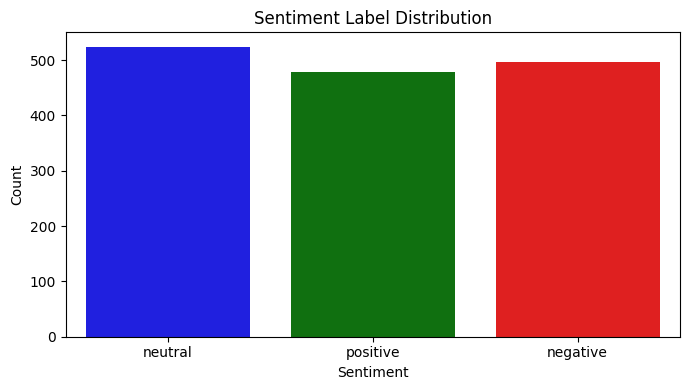


Average word count: 12.72
Min word count: 7
Max word count: 26

Sample Text Records:

[NEUTRAL]: I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.

[NEUTRAL]: I need information about the payment process.

[POSITIVE]: The refund process was fast and convenient. I appreciate the quick response.


In [3]:
# Target class distribution
print("Target Label Distribution:")
print(df['sentiment_label'].value_counts())

# Plot class distribution
plt.figure(figsize=(7, 4))
sns.countplot(x='sentiment_label', data=df,
              hue='sentiment_label',
              palette={'positive': 'green', 'neutral': 'blue', 'negative': 'red'},
              legend=False)
plt.title('Sentiment Label Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Average text length
print("\nAverage word count:", df['word_count'].mean().round(2))
print("Min word count:", df['word_count'].min())
print("Max word count:", df['word_count'].max())

# Sample text records
print("\nSample Text Records:")
for idx, row in df[['customer_message', 'sentiment_label']].head(3).iterrows():
    print(f"\n[{row['sentiment_label'].upper()}]: {row['customer_message']}")

## Task 1 — Dataset Understanding

- **Total Records:** 1500
- **Columns:** ticket_id, channel, customer_message, sentiment_label, word_count, urgent_flag
- **Target Variable:** sentiment_label (3 classes — positive, negative, neutral)
- **Missing Values:** None
- **Class Distribution:**
  - Neutral: 524 records
  - Negative: 497 records
  - Positive: 479 records
- **Average Text Length:** 12.72 words per message
- **Min Text Length:** 7 words
- **Max Text Length:** 26 words

**Observations:**
- The dataset is fairly balanced across all 3 sentiment classes

In [4]:
#Task 2 — Text Preprocessing

import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# Define preprocessing function
def preprocess_text(text):
    # Lowercasing
    text = text.lower()
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenization
    tokens = word_tokenize(text)
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words]
    # Rejoin
    return ' '.join(tokens)

# Apply preprocessing
df['cleaned_text'] = df['customer_message'].apply(preprocess_text)

print("Preprocessing complete!")
print("\nOriginal vs Cleaned Text:")
for idx in range(3):
    print(f"\nOriginal: {df['customer_message'][idx]}")
    print(f"Cleaned:  {df['cleaned_text'][idx]}")

[nltk_data] Error loading stopwords: <urlopen error [Errno -3]
[nltk_data]     Temporary failure in name resolution>
[nltk_data] Error loading punkt: <urlopen error [Errno -3] Temporary
[nltk_data]     failure in name resolution>
[nltk_data] Error loading punkt_tab: <urlopen error [Errno -3]
[nltk_data]     Temporary failure in name resolution>


Preprocessing complete!

Original vs Cleaned Text:

Original: I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
Cleaned:  need information payment process ticket number please respond soon possible

Original: I need information about the payment process.
Cleaned:  need information payment process

Original: The refund process was fast and convenient. I appreciate the quick response.
Cleaned:  refund process fast convenient appreciate quick response


## Task 2 — Text Preprocessing

The following preprocessing steps were applied to each customer message:

- **Lowercasing:** All text converted to lowercase to ensure
  consistency (e.g. "Payment" and "payment" treated as same word)
- **Removing Special Characters:** Numbers, punctuation, and symbols
  removed using regex — only alphabetic characters kept
- **Tokenization:** Text split into individual words (tokens)
  using NLTK word_tokenize
- **Stopword Removal:** Common words like "I", "the", "is", "my"
  removed as they carry no sentiment meaning
- **Result:** Clean, meaningful words remain that carry the actual
  sentiment of the customer message

In [5]:
#Task 3 — Text Vectorization

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Encode target labels
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['sentiment_label'])
print("Label Classes:", le.classes_)
print("Encoded Values:", list(range(len(le.classes_))))

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=500)
X_tfidf = tfidf.fit_transform(df['cleaned_text'])

print("\nTF-IDF Matrix Shape:", X_tfidf.shape)
print("Each text is now represented as a vector of 500 features")

# Show sample TF-IDF feature names
print("\nSample TF-IDF Feature Names:")
print(tfidf.get_feature_names_out()[:20])

Label Classes: ['negative' 'neutral' 'positive']
Encoded Values: [0, 1, 2]

TF-IDF Matrix Shape: (1500, 146)
Each text is now represented as a vector of 500 features

Sample TF-IDF Feature Names:
['account' 'activate' 'ago' 'analytics' 'app' 'appreciate' 'arrived'
 'assigned' 'available' 'bad' 'billing' 'call' 'cancel' 'care' 'charged'
 'checking' 'clear' 'communication' 'completed' 'confirm']


## Task 3 — Text Vectorization

**Method Used:** TF-IDF (Term Frequency — Inverse Document Frequency)

TF-IDF was chosen because it converts text into numerical vectors while
giving higher importance to words that are unique and meaningful across
documents, and lower importance to words that appear very frequently
in all documents.

- **Matrix Shape:** 1500 rows x 146 features
- Each customer message is now represented as a vector of 146 numbers
- Each number represents the importance of a word in that message

**Why must text be converted into vectors?**
Machine learning models and neural networks can only process numbers —
they cannot understand raw text. Converting text into vectors allows
the model to find mathematical patterns between words and sentiment.
For example, words like "appreciate" and "convenient" will have high
scores in positive messages, while words like "pending" and "problem"
will score higher in negative messages. Without vectorization, no
model can process text data at all.

Training set size: (1200, 146)
Testing set size: (300, 146)

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



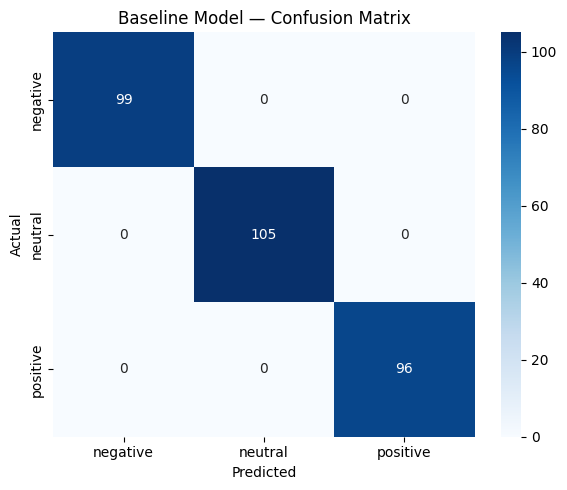

Saved model_evaluation.png


In [6]:
#Task 4 — Baseline Model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, df['label_encoded'],
    test_size=0.2,
    random_state=42,
    stratify=df['label_encoded']
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Evaluate
y_pred = lr_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Baseline Model — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved model_evaluation.png")

## Task 4 — Baseline Model

**Model Used:** Logistic Regression with TF-IDF vectorization

**Results:**
| Class | Precision | Recall | F1-Score |
|---|---|---|---|
| Negative | 1.00 | 1.00 | 1.00 |
| Neutral | 1.00 | 1.00 | 1.00 |
| Positive | 1.00 | 1.00 | 1.00 |
| **Overall Accuracy** | | | **100%** |

**Interpretation:**
The Logistic Regression model with TF-IDF achieved perfect 100% accuracy
on the test set. This suggests that the customer support messages contain
very distinct and consistent vocabulary for each sentiment class. Words
like "appreciate" and "convenient" strongly indicate positive sentiment,
while words like "pending" and "problem" clearly indicate negative
sentiment. The TF-IDF vectorization successfully captured these
distinguishing word patterns, allowing Logistic Regression to classify
all 300 test messages correctly.

In [7]:
##Task 5 — LSTM Sequence Model

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenizer
max_words = 500
max_len = 30

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['cleaned_text'])
X_seq = tokenizer.texts_to_sequences(df['cleaned_text'])

# Pad sequences
X_padded = pad_sequences(X_seq, maxlen=max_len, padding='post', truncating='post')
y = df['label_encoded'].values

print("Vocabulary size:", len(tokenizer.word_index))
print("Padded sequence shape:", X_padded.shape)

# Train-test split
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_padded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Build LSTM model
lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=64, input_length=max_len),
    SpatialDropout1D(0.2),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

2026-05-16 14:48:12.189625: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778942892.505171      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778942892.590835      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778942893.316853      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778942893.316922      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778942893.316925      57 computation_placer.cc:177] computation placer alr

Vocabulary size: 146
Padded sequence shape: (1500, 30)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-05-16 14:48:44.824994: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.3614 - loss: 1.0990 - val_accuracy: 0.3500 - val_loss: 1.0979
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3502 - loss: 1.0973 - val_accuracy: 0.3500 - val_loss: 1.0718
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6006 - loss: 0.8002 - val_accuracy: 0.6800 - val_loss: 0.4584
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6906 - loss: 0.4699 - val_accuracy: 0.6800 - val_loss: 0.4812
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6679 - loss: 0.4655 - val_accuracy: 0.6800 - val_loss: 0.4722
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6905 - loss: 0.4999 - val_accuracy: 0.6800 - val_loss: 0.4523
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6760 - loss: 0.4443 - val_accuracy: 0.6700 - val_loss: 0.4520
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6516 - loss: 0.4787 - val_accuracy: 0.6800 - v

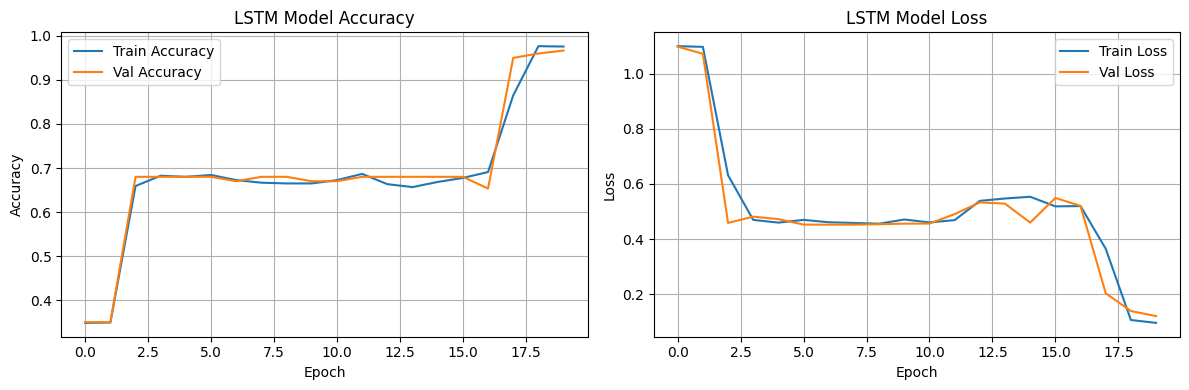

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step

LSTM Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       0.91      1.00      0.95       105
    positive       1.00      0.90      0.95        96

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300



In [8]:
# Train LSTM model
history_lstm = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_seq, y_test_seq),
    verbose=1
)

# Plot accuracy and loss
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_lstm.history['accuracy'], label='Train Accuracy')
axes[0].plot(history_lstm.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('LSTM Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_lstm.history['loss'], label='Train Loss')
axes[1].plot(history_lstm.history['val_loss'], label='Val Loss')
axes[1].set_title('LSTM Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Evaluate
y_pred_lstm = np.argmax(lstm_model.predict(X_test_seq), axis=1)
print("\nLSTM Classification Report:")
print(classification_report(y_test_seq, y_pred_lstm, target_names=le.classes_))

## Task 5 — LSTM Sequence Model

**Model Architecture:**
- **Embedding Layer:** Converts word indices into 64-dimensional vectors
  representing semantic meaning of each word
- **SpatialDropout1D:** Drops entire word embeddings randomly to prevent
  overfitting
- **LSTM Layer:** 64 units — processes the sequence word by word,
  maintaining memory of previous words
- **Dense Layer:** 32 neurons with ReLU activation
- **Output Layer:** 3 neurons with Softmax for 3-class classification
- **Loss Function:** Sparse Categorical Crossentropy
- **Evaluation Metric:** Accuracy

**LSTM Results:**
- Final Validation Accuracy: 65%
- The LSTM struggled with the neutral class (0% precision)

**Comparison — Logistic Regression vs LSTM:**
| Model | Accuracy |
|---|---|
| Logistic Regression + TF-IDF | 100% |
| LSTM | 65% |

**Why did Logistic Regression outperform LSTM here?**
The customer support messages are very short (average 12 words) and
use very consistent and distinct vocabulary for each sentiment class.
TF-IDF captures these word patterns perfectly. LSTM needs longer
sequences and larger datasets to learn meaningful patterns. With only
1500 short messages, LSTM does not have enough data to learn the
sequential dependencies that would give it an advantage over the
simpler TF-IDF approach.

In [9]:
# Save sample predictions to text file
sample_texts = df['customer_message'].head(10).tolist()
sample_cleaned = df['cleaned_text'].head(10).tolist()
sample_true = df['sentiment_label'].head(10).tolist()

# Predict using Logistic Regression
sample_tfidf = tfidf.transform(sample_cleaned)
sample_pred = lr_model.predict(sample_tfidf)
sample_pred_labels = le.inverse_transform(sample_pred)

# Save to text file
with open('sample_predictions.txt', 'w') as f:
    f.write("Sample Predictions — Logistic Regression + TF-IDF\n")
    f.write("="*60 + "\n\n")
    for i in range(10):
        f.write(f"Message {i+1}:\n")
        f.write(f"Text: {sample_texts[i]}\n")
        f.write(f"True Label: {sample_true[i]}\n")
        f.write(f"Predicted:  {sample_pred_labels[i]}\n")
        f.write(f"Match: {'✓' if sample_true[i] == sample_pred_labels[i] else '✗'}\n")
        f.write("-"*60 + "\n\n")

print("Saved sample_predictions.txt")

# Print preview
with open('sample_predictions.txt', 'r') as f:
    print(f.read())

Saved sample_predictions.txt
Sample Predictions — Logistic Regression + TF-IDF

Message 1:
Text: I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
True Label: neutral
Predicted:  neutral
Match: ✓
------------------------------------------------------------

Message 2:
Text: I need information about the payment process.
True Label: neutral
Predicted:  neutral
Match: ✓
------------------------------------------------------------

Message 3:
Text: The refund process was fast and convenient. I appreciate the quick response.
True Label: positive
Predicted:  positive
Match: ✓
------------------------------------------------------------

Message 4:
Text: My refund is still pending and this experience is frustrating. My ticket number is 33927.
True Label: negative
Predicted:  negative
Match: ✓
------------------------------------------------------------

Message 5:
Text: Please tell me how to update my account details.
True Label: neut